# Klasifikasi — Favorita Sales Forecasting (Stage 1)

## 1.Load Data

In [1]:
from google.colab import drive
drive.mount("/content/drive")
path = "/content/drive/MyDrive/Data Mining/"


Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score
import joblib

transactions = pd.read_csv(path + "transactions.csv", sep=",", encoding="latin-1", low_memory=False)
train        = pd.read_csv(path + "train.csv",        sep=",", encoding="latin-1", low_memory=False)
test         = pd.read_csv(path + "test.csv",         sep=",", encoding="latin-1", low_memory=False)
store        = pd.read_csv(path + "stores.csv",       sep=",", encoding="latin-1", low_memory=False)
oil          = pd.read_csv(path + "oil.csv",          sep=",", encoding="latin-1", low_memory=False)
event        = pd.read_csv(path + "holidays_events.csv", sep=",", encoding="latin-1", low_memory=False)

for name, df in [("Transactions", transactions), ("Train", train), ("Test", test),
                 ("Store", store), ("Oil", oil), ("Event", event)]:
    print(f"{name}: {len(df):,} baris")


Transactions: 83,488 baris
Train: 3,000,888 baris
Test: 28,512 baris
Store: 54 baris
Oil: 1,218 baris
Event: 350 baris


## 2. Preprocessing

In [3]:
# Konversi tipe tanggal
transactions["date"] = pd.to_datetime(transactions["date"])
train["date"]        = pd.to_datetime(train["date"])
test["date"]         = pd.to_datetime(test["date"])
oil["date"]          = pd.to_datetime(oil["date"])
event["date"]        = pd.to_datetime(event["date"])

# Agregasi event per tanggal
event_simple = event.groupby("date").agg({
    "type":        "first",
    "locale":      "first",
    "locale_name": "first",
    "description": "first",
    "transferred": "first"
}).reset_index()

# Forward fill harga minyak
oil["dcoilwtico"] = oil["dcoilwtico"].ffill()


In [4]:
# Merge
df = train.merge(store,         on="store_nbr",           how="left")
df = df.merge(transactions,     on=["date", "store_nbr"],  how="left")
df = df.merge(oil,              on="date",                 how="left")
df = df.merge(event_simple,     on="date",                 how="left")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type_x        object        
 9   cluster       int64         
 10  transactions  float64       
 11  dcoilwtico    float64       
 12  type_y        object        
 13  locale        object        
 14  locale_name   object        
 15  description   object        
 16  transferred   object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 389.2+ MB


## 3. Label Binary

- is_sold = 1 → sales > 0 (ada penjualan)
- is_sold = 0 → sales = 0 (tidak ada penjualan)

In [5]:
# Membuat label biner
df['is_sold'] = (df['sales'] > 0).astype(int)

# Cek distribusi label
print("Distribusi label is_sold:")
print(df['is_sold'].value_counts(normalize=True))


Distribusi label is_sold:
is_sold
1    0.687049
0    0.312951
Name: proportion, dtype: float64


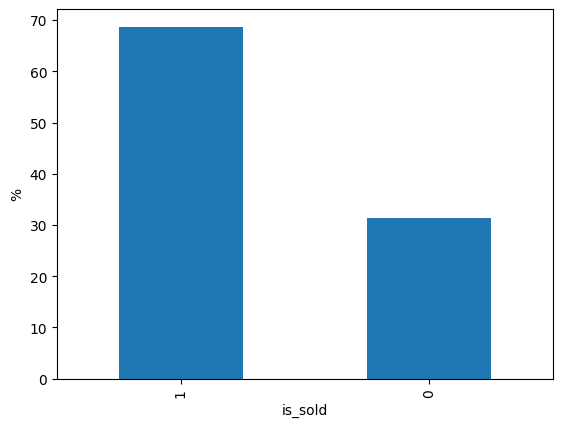

In [22]:
df['is_sold'].value_counts(normalize=True).mul(100).plot(kind='bar')
plt.ylabel('%')
plt.show()

## 4. Data Preparation

### 4.1 Pemeriksaan Data

In [6]:
# Cek null value
print("Null values:")
print(df.isnull().sum())

# Cek nilai unik kolom kategorik
print("\nNilai unik kolom kategorik:")
for col in ['family', 'type_x', 'type_y', 'locale', 'city', 'state', 'transferred']:
    print(f"  {col}: {df[col].nunique()} unique")


Null values:
id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type_x                0
cluster               0
transactions     245784
dcoilwtico       858924
type_y          2551824
locale          2551824
locale_name     2551824
description     2551824
transferred     2551824
is_sold               0
dtype: int64

Nilai unik kolom kategorik:
  family: 33 unique
  type_x: 5 unique
  type_y: 6 unique
  locale: 3 unique
  city: 22 unique
  state: 16 unique
  transferred: 2 unique


### 4.2 Fitur Selection

Kolom yang di hapus:
- id: tidak bermanfaat
- description: memiliki 93 nilai unik
- locale_name: sudah terwakili oleh locale
- sales: tidak digunakan pada klasifikasi, hanya pada regressi (dapat menyebabkan data leakage)
- transactions: data leakage

In [7]:
df = df.drop(['id', 'description', 'locale_name', 'sales', 'transactions'], axis=1)
print(f"Shape setelah drop: {df.shape}")


Shape setelah drop: (3000888, 13)


### 4.3 Penanganan Missing Value

In [8]:
# Penanganan missing value kolom event
df['type_y']      = df['type_y'].fillna('None')
df['locale']      = df['locale'].fillna('None')
df['transferred'] = df['transferred'].fillna('False')
df['transferred'] = df['transferred'].replace('False', False).astype(str)

# Forward & backward fill harga minyak
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()

print("Cek null value lagi:")
print(df.isnull().sum())


Cek null value lagi:
date           0
store_nbr      0
family         0
onpromotion    0
city           0
state          0
type_x         0
cluster        0
dcoilwtico     0
type_y         0
locale         0
transferred    0
is_sold        0
dtype: int64


### 4.4 Feature Engineering Waktu & Lag Harga Minyak

In [9]:
df['day_of_week']  = df['date'].dt.dayofweek
df['month']        = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day
df['year']         = df['date'].dt.year
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# Lag harga minyak 1 hari
df = df.sort_values('date').reset_index(drop=True)
df['dcoilwtico'] = df['dcoilwtico'].shift(1)
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()
df.dropna(subset=['dcoilwtico'], inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 18 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   store_nbr     int64         
 2   family        object        
 3   onpromotion   int64         
 4   city          object        
 5   state         object        
 6   type_x        object        
 7   cluster       int64         
 8   dcoilwtico    float64       
 9   type_y        object        
 10  locale        object        
 11  transferred   object        
 12  is_sold       int64         
 13  day_of_week   int32         
 14  month         int32         
 15  day_of_month  int32         
 16  year          int32         
 17  week_of_year  int64         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(5), object(7)
memory usage: 366.3+ MB


## 5. Train/Test Split (Time-Based)

- Training set: 1 Januari 2013 – 31 Mei 2017
- Testing set: 1 Juni 2017 – 15 Agustus 2017

In [10]:
cutoff = pd.Timestamp('2017-06-01')

X_train = df[df['date'] < cutoff].drop(columns=['date', 'is_sold'])
X_test  = df[df['date'] >= cutoff].drop(columns=['date', 'is_sold'])
y_train = df[df['date'] < cutoff]['is_sold']
y_test  = df[df['date'] >= cutoff]['is_sold']

print(f"Train : {len(X_train):,} baris")
print(f"Test  : {len(X_test):,} baris")
print(f"Fitur : {X_train.shape[1]}")
print(f"\nKolom: {X_train.columns.tolist()}")


Train : 2,865,456 baris
Test  : 135,432 baris
Fitur : 16

Kolom: ['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'type_y', 'locale', 'transferred', 'day_of_week', 'month', 'day_of_month', 'year', 'week_of_year']


## 6. Modeling

### 6.1 LightGBM Classifier

In [11]:
import lightgbm as lgb

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
le_dict_lgbm = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_dict_lgbm[col] = le

model_lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

model_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_train_pred = model_lgbm.predict(X_train)
y_test_pred  = model_lgbm.predict(X_test)

print(f"Accuracy Training : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy Testing  : {accuracy_score(y_test,  y_test_pred):.4f}")
print(f"F1 Training       : {f1_score(y_train, y_train_pred):.4f}")
print(f"F1 Testing        : {f1_score(y_test,  y_test_pred):.4f}")
print(f"Recall Training   : {recall_score(y_train, y_train_pred):.4f}")
print(f"Recall Testing    : {recall_score(y_test,  y_test_pred):.4f}")
print("\n", classification_report(y_test, y_test_pred))


Accuracy Training : 0.9471
Accuracy Testing  : 0.9482
F1 Training       : 0.9614
F1 Testing        : 0.9701
Recall Training   : 0.9716
Recall Testing    : 0.9818

               precision    recall  f1-score   support

           0       0.87      0.75      0.81     19491
           1       0.96      0.98      0.97    115941

    accuracy                           0.95    135432
   macro avg       0.92      0.86      0.89    135432
weighted avg       0.95      0.95      0.95    135432



### 6.2 Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X_train_lr = df[df['date'] < cutoff].drop(columns=['date', 'is_sold'])
X_test_lr  = df[df['date'] >= cutoff].drop(columns=['date', 'is_sold'])
y_train_lr = df[df['date'] < cutoff]['is_sold']
y_test_lr  = df[df['date'] >= cutoff]['is_sold']

X_train_s = X_train_lr.sample(frac=0.1, random_state=42)
y_train_s = y_train_lr.loc[X_train_s.index]

cat_cols_lr = X_train_lr.select_dtypes(include='object').columns.tolist()
num_cols_lr = X_train_lr.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore'), cat_cols_lr),
    ('num', StandardScaler(), num_cols_lr)
])

param_distributions = {
    'classifier__C':            [0.01, 0.1, 1],
    'classifier__class_weight': [None, 'balanced'],
}

model_lr_pipeline = Pipeline([
    ('preprocess',  preprocessor),
    ('classifier',  LogisticRegression(max_iter=500, solver='saga', n_jobs=-1, random_state=42))
])

random_search = RandomizedSearchCV(
    estimator=model_lr_pipeline,
    param_distributions=param_distributions,
    n_iter=4, cv=2, scoring='f1',
    n_jobs=-1, random_state=42, verbose=1
)

random_search.fit(X_train_s, y_train_s)
best_params = random_search.best_params_
print("Best Params:", best_params)

final_lr = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        C=best_params['classifier__C'],
        class_weight=best_params['classifier__class_weight'],
        max_iter=500, solver='saga', n_jobs=-1, random_state=42
    ))
])

final_lr.fit(X_train_lr, y_train_lr)

y_train_pred = final_lr.predict(X_train_lr)
y_test_pred  = final_lr.predict(X_test_lr)

print(f"Accuracy Training : {accuracy_score(y_train_lr, y_train_pred):.4f}")
print(f"Accuracy Testing  : {accuracy_score(y_test_lr,  y_test_pred):.4f}")
print(f"F1 Training       : {f1_score(y_train_lr, y_train_pred):.4f}")
print(f"F1 Testing        : {f1_score(y_test_lr,  y_test_pred):.4f}")
print(f"Recall Training   : {recall_score(y_train, y_train_pred):.4f}")
print(f"Recall Testing    : {recall_score(y_test,  y_test_pred):.4f}")
print("\n", classification_report(y_test_lr, y_test_pred))


Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best Params: {'classifier__class_weight': None, 'classifier__C': 0.1}
Accuracy Training : 0.8573
Accuracy Testing  : 0.9061
F1 Training       : 0.8973
F1 Testing        : 0.9466
Recall Training   : 0.9174
Recall Testing    : 0.9717

               precision    recall  f1-score   support

           0       0.75      0.52      0.61     19491
           1       0.92      0.97      0.95    115941

    accuracy                           0.91    135432
   macro avg       0.84      0.74      0.78    135432
weighted avg       0.90      0.91      0.90    135432



### 6.3 Random Forest Classifier

In [13]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

model_rf.fit(X_train, y_train)

y_train_pred = model_rf.predict(X_train)
y_test_pred  = model_rf.predict(X_test)

print(f"Accuracy Training : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy Testing  : {accuracy_score(y_test,  y_test_pred):.4f}")
print(f"F1 Training       : {f1_score(y_train, y_train_pred):.4f}")
print(f"F1 Testing        : {f1_score(y_test,  y_test_pred):.4f}")
print(f"Recall Training   : {recall_score(y_train, y_train_pred):.4f}")
print(f"Recall Testing    : {recall_score(y_test,  y_test_pred):.4f}")
print("\n", classification_report(y_test, y_test_pred))


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.3min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    4.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished


Accuracy Training : 0.8596
Accuracy Testing  : 0.8998
F1 Training       : 0.9031
F1 Testing        : 0.9437
Recall Training   : 0.9637
Recall Testing    : 0.9797

               precision    recall  f1-score   support

           0       0.78      0.42      0.55     19491
           1       0.91      0.98      0.94    115941

    accuracy                           0.90    135432
   macro avg       0.84      0.70      0.75    135432
weighted avg       0.89      0.90      0.89    135432



### 6.4 XGBoost Classifier

In [14]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=50,
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric='logloss'
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_train_pred = model_xgb.predict(X_train)
y_test_pred  = model_xgb.predict(X_test)

print(f"Accuracy Training : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy Testing  : {accuracy_score(y_test,  y_test_pred):.4f}")
print(f"F1 Training       : {f1_score(y_train, y_train_pred):.4f}")
print(f"F1 Testing        : {f1_score(y_test,  y_test_pred):.4f}")
print(f"Recall Training   : {recall_score(y_train, y_train_pred):.4f}")
print(f"Recall Testing    : {recall_score(y_test,  y_test_pred):.4f}")
print("\n", classification_report(y_test, y_test_pred))


Accuracy Training : 0.9241
Accuracy Testing  : 0.9435
F1 Training       : 0.9451
F1 Testing        : 0.9672
Recall Training   : 0.9621
Recall Testing    : 0.9730

               precision    recall  f1-score   support

           0       0.83      0.77      0.80     19491
           1       0.96      0.97      0.97    115941

    accuracy                           0.94    135432
   macro avg       0.89      0.87      0.88    135432
weighted avg       0.94      0.94      0.94    135432



### 6.5 CatBoost Classifier

In [15]:
!pip install catboost -q
from catboost import CatBoostClassifier

X_train_cb = df[df['date'] < cutoff].drop(columns=['date', 'is_sold'])
X_test_cb  = df[df['date'] >= cutoff].drop(columns=['date', 'is_sold'])
y_train_cb = df[df['date'] < cutoff]['is_sold']
y_test_cb  = df[df['date'] >= cutoff]['is_sold']

cat_cols_cb = X_train_cb.select_dtypes(include='object').columns.tolist()
cat_idx     = [X_train_cb.columns.tolist().index(col) for col in cat_cols_cb]

model_cb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    min_child_samples=50,
    eval_metric='F1',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=0
)

model_cb.fit(
    X_train_cb, y_train_cb,
    cat_features=cat_idx,
    eval_set=(X_test_cb, y_test_cb)
)

y_train_pred = model_cb.predict(X_train_cb)
y_test_pred  = model_cb.predict(X_test_cb)

print(f"Accuracy Training : {accuracy_score(y_train_cb, y_train_pred):.4f}")
print(f"Accuracy Testing  : {accuracy_score(y_test_cb,  y_test_pred):.4f}")
print(f"F1 Training       : {f1_score(y_train_cb, y_train_pred):.4f}")
print(f"F1 Testing        : {f1_score(y_test_cb,  y_test_pred):.4f}")
print(f"Recall Training   : {recall_score(y_train, y_train_pred):.4f}")
print(f"Recall Testing    : {recall_score(y_test,  y_test_pred):.4f}")
print("\n", classification_report(y_test_cb, y_test_pred))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
Accuracy Training : 0.9435
Accuracy Testing  : 0.9391
F1 Training       : 0.9587
F1 Testing        : 0.9643
Recall Training   : 0.9646
Recall Testing    : 0.9589

               precision    recall  f1-score   support

           0       0.77      0.82      0.80     19491
           1       0.97      0.96      0.96    115941

    accuracy                           0.94    135432
   macro avg       0.87      0.89      0.88    135432
weighted avg       0.94      0.94      0.94    135432



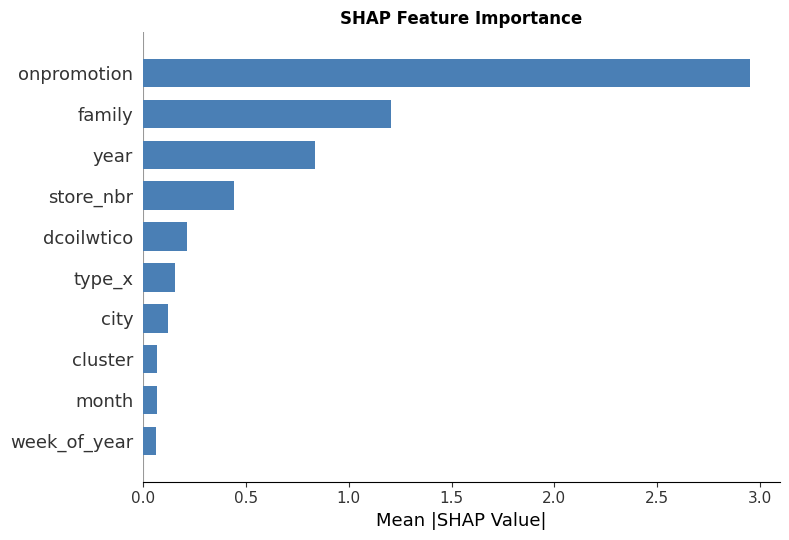

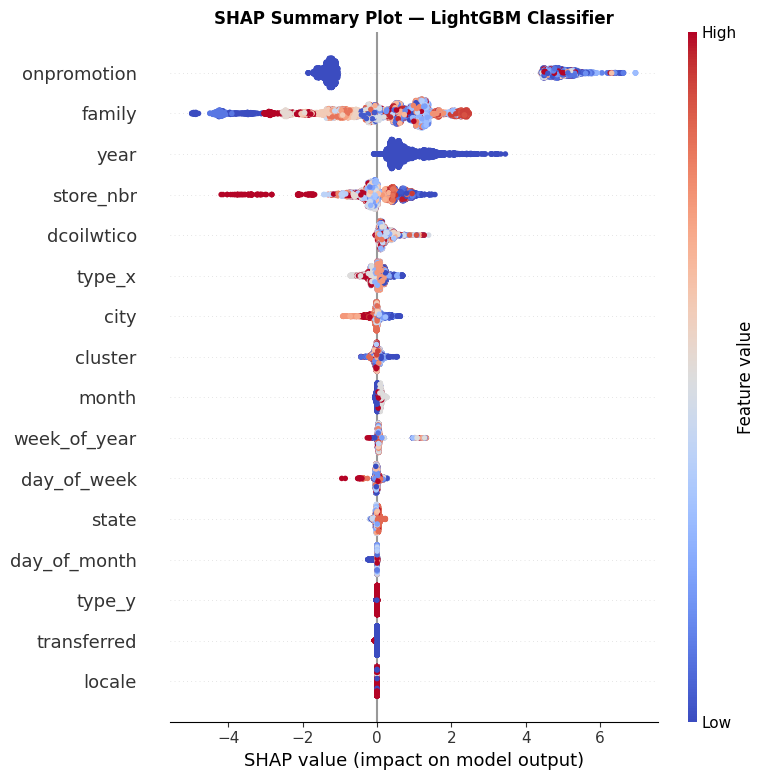

In [18]:
import shap
import matplotlib.pyplot as plt

X_test_sample = X_test.sample(n=5000, random_state=42)

explainer   = shap.TreeExplainer(model_lgbm)
shap_values = explainer.shap_values(X_test_sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(
    sv, X_test_sample,
    plot_type="bar",
    max_display=10,
    show=False,
    color="#4A7FB5"
)
plt.title("SHAP Feature Importance", fontsize=12, fontweight='bold')
plt.xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()

shap.summary_plot(
    sv, X_test_sample,
    show=False,
    cmap=plt.cm.coolwarm
)
plt.title("SHAP Summary Plot — LightGBM Classifier", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

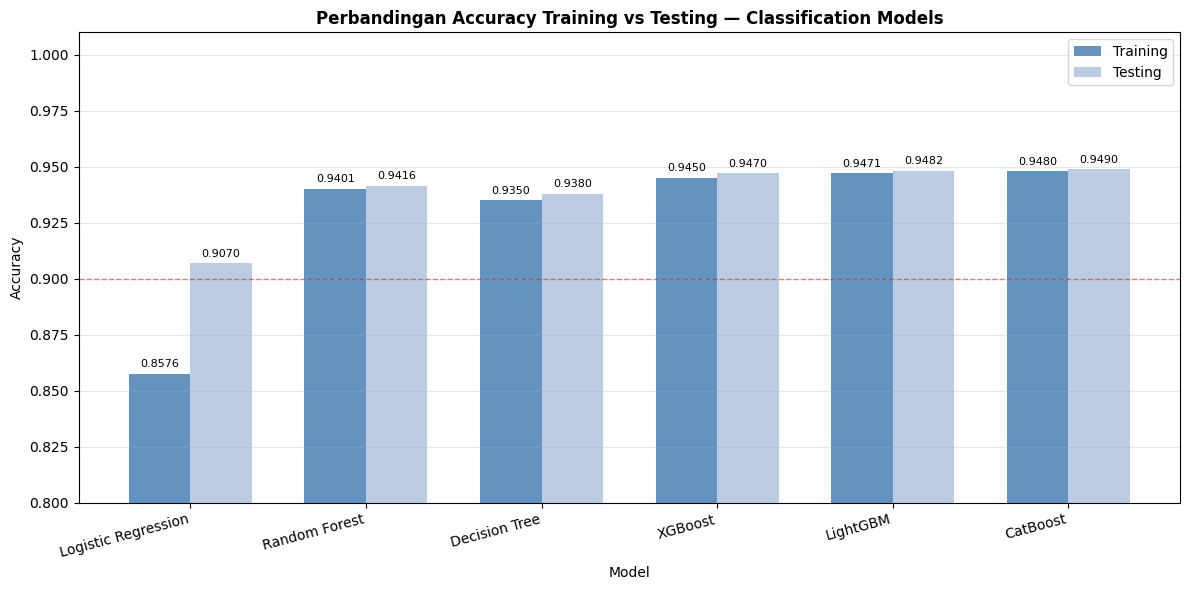

In [20]:
import matplotlib.pyplot as plt
import numpy as np

models     = ['Logistic Regression', 'Random Forest', 'Decision Tree', 'XGBoost', 'LightGBM', 'CatBoost']
acc_train  = [0.8576, 0.9401, 0.9350, 0.9450, 0.9471, 0.9480]  # ganti dengan nilai aktual kamu
acc_test   = [0.9070, 0.9416, 0.9380, 0.9470, 0.9482, 0.9490]  # ganti dengan nilai aktual kamu

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, acc_train, width, label='Training', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, acc_test,  width, label='Testing',  color='lightsteelblue', alpha=0.85)

# Tambahkan nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Perbandingan Accuracy Training vs Testing — Classification Models',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0.80, 1.01)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.90, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Threshold 0.90')

plt.tight_layout()
plt.show()

## 7. Simpan Model Terbaik

In [16]:
joblib.dump(model_lgbm, path + 'model_klasifikasi.pkl')

joblib.dump(le_dict_lgbm, path + 'label_encoders_clf.pkl')

joblib.dump(X_train.columns.tolist(), path + 'feature_columns_clf.pkl')


['/content/drive/MyDrive/Data Mining/feature_columns_clf.pkl']